# Imports e conexão

In [48]:
import Connection as conn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings # só para não ficar reclamando
warnings.filterwarnings("ignore")

In [57]:
headers = conn.get_conn('matheus_root','server@Database')
df, df_tratado = conn.get_dataset_completo(headers)
print(f'DF bruto: {df.shape[0]} registros, {df.shape[1]} colunas')
print(f'DF tratado: {df_tratado.shape[0]} registros, {df_tratado.shape[1]} colunas')
df.head()

DF bruto: 1460 registros, 24 colunas
DF tratado: 1460 registros, 24 colunas


,id,ms_subclass,ms_zoning,lot_area,street,neighborhood,overall_qual,overall_cond,year_built,year_remod_add,...,kitchen_abvgr,totrms_abvgrd,garage_cars,garage_area,sale_price,house_age,remod_age,total_bath,area_per_room,price_category
0,1,60,RL,8450,Pave,CollgCr,7,5,2003,2003,...,1,8,2.0,548.0,208500,21,21,2.5,213.750000,1
1,2,20,RL,9600,Pave,Veenker,6,8,1976,1976,...,1,6,2.0,460.0,181500,48,48,2.0,210.333333,1
2,3,60,RL,11250,Pave,CollgCr,7,5,2001,2002,...,1,6,2.0,608.0,223500,23,22,2.5,297.666667,1
3,4,70,RL,9550,Pave,Crawfor,7,5,1915,1970,...,1,7,3.0,642.0,140000,109,54,1.0,245.285714,0
4,5,60,RL,14260,Pave,NoRidge,8,5,2000,2000,...,1,9,3.0,836.0,250000,24,24,2.5,244.222222,1


# 1. Análise Exploratória EDA
### 1.1 Visão geral do dataset

In [50]:
print('Tipos de variáveis')
print('\nVariáveis numéricas:', df.select_dtypes(include='number').columns.tolist())
print('\nVariáveis categóricas:', df.select_dtypes(include='object').columns.tolist())

Tipos de variáveis

Variáveis numéricas: ['id', 'ms_subclass', 'lot_area', 'overall_qual', 'overall_cond', 'year_built', 'year_remod_add', 'gr_liv_area', 'full_bath', 'half_bath', 'bedroom_abvgr', 'kitchen_abvgr', 'totrms_abvgrd', 'garage_cars', 'garage_area', 'sale_price', 'house_age', 'remod_age', 'total_bath', 'area_per_room', 'price_category']

Variáveis categóricas: ['ms_zoning', 'street', 'neighborhood']


### 1.2 Valores Faltantes

In [51]:
missing = conn.get_missing(headers)
missing_df = pd.DataFrame(missing['missing_values']).T
missing_df = missing_df[missing_df['missing'] > 0].sort_values('missing_pct', ascending=True)

if missing_df.empty:
    print("Não tem valores faltantes")
else:
    print(missing_df)
    fig, ax = plt.subplots()
    missing_df['missing_pct'].plot(kind='bar', ax=ax, color='salmon')
    ax.set_title('Percentual de Valores Faltantes por Coluna')
    ax.set_ylabel('% Faltante')
    ax.set_xlabel('Coluna')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Não tem valores faltantes


### 1.3 Distruibuição do preço de venda

=== Distribuição do Preço de Venda ===
  min: $34,900.00
  max: $755,000.00
  media: $180,921.20
  q1: $129,975.00
  mediana: $163,000.00
  q3: $214,000.00


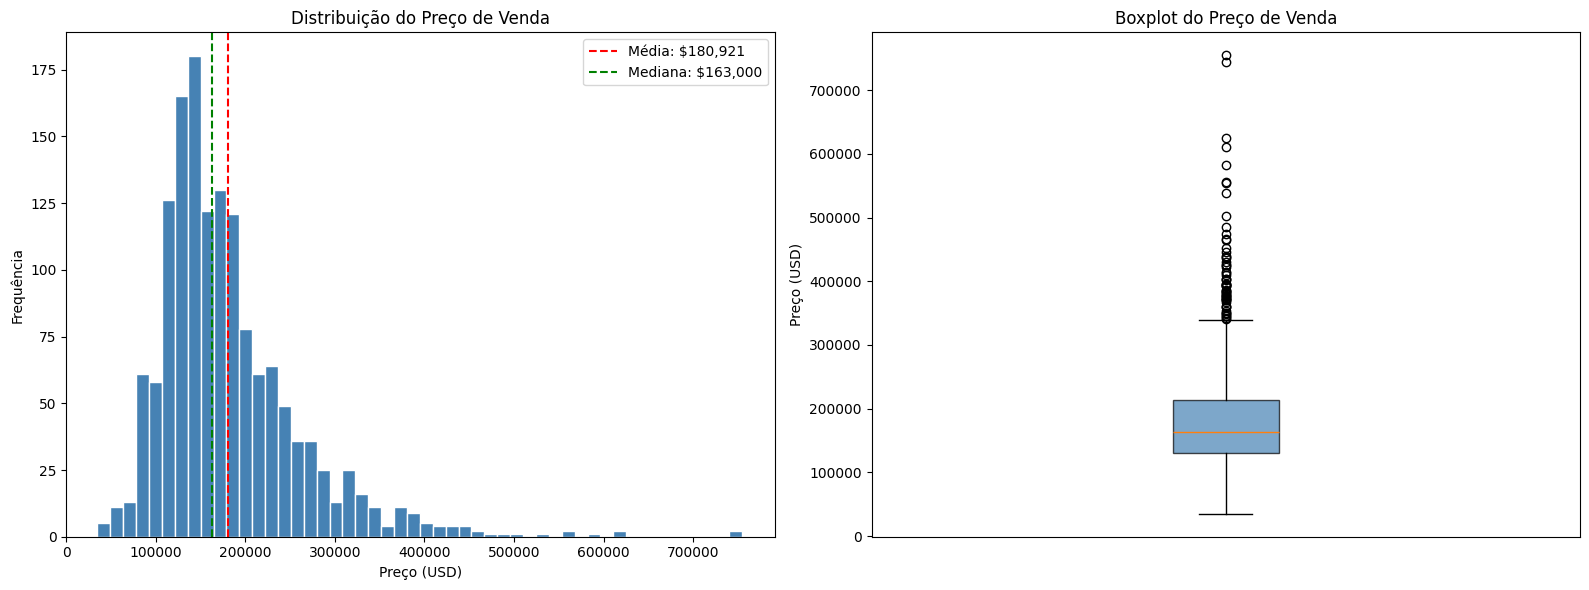

In [52]:
dist = conn.get_distribution(headers)['distribuicao_preco']
print("=== Distribuição do Preço de Venda ===")
for k, v in dist.items():
    print(f"  {k}: ${v:,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma
axes[0].hist(df['sale_price'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(dist['media'], color='red', linestyle='--', label=f"Média: ${dist['media']:,.0f}")
axes[0].axvline(dist['mediana'], color='green', linestyle='--', label=f"Mediana: ${dist['mediana']:,.0f}")
axes[0].set_title('Distribuição do Preço de Venda')
axes[0].set_xlabel('Preço (USD)')
axes[0].set_ylabel('Frequência')
axes[0].legend()
axes[0].ticklabel_format(style='plain', axis='x')
axes[0].set_xlim(left=0)

# Boxplot
axes[1].boxplot(df['sale_price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot do Preço de Venda')
axes[1].set_ylabel('Preço (USD)')
axes[1].set_xticks([])
axes[1].tick_params(axis='x', which='both', bottom=False, labelbottom=False)


plt.tight_layout()
plt.show()

### 1.4 Correlações com o Preço de Venda

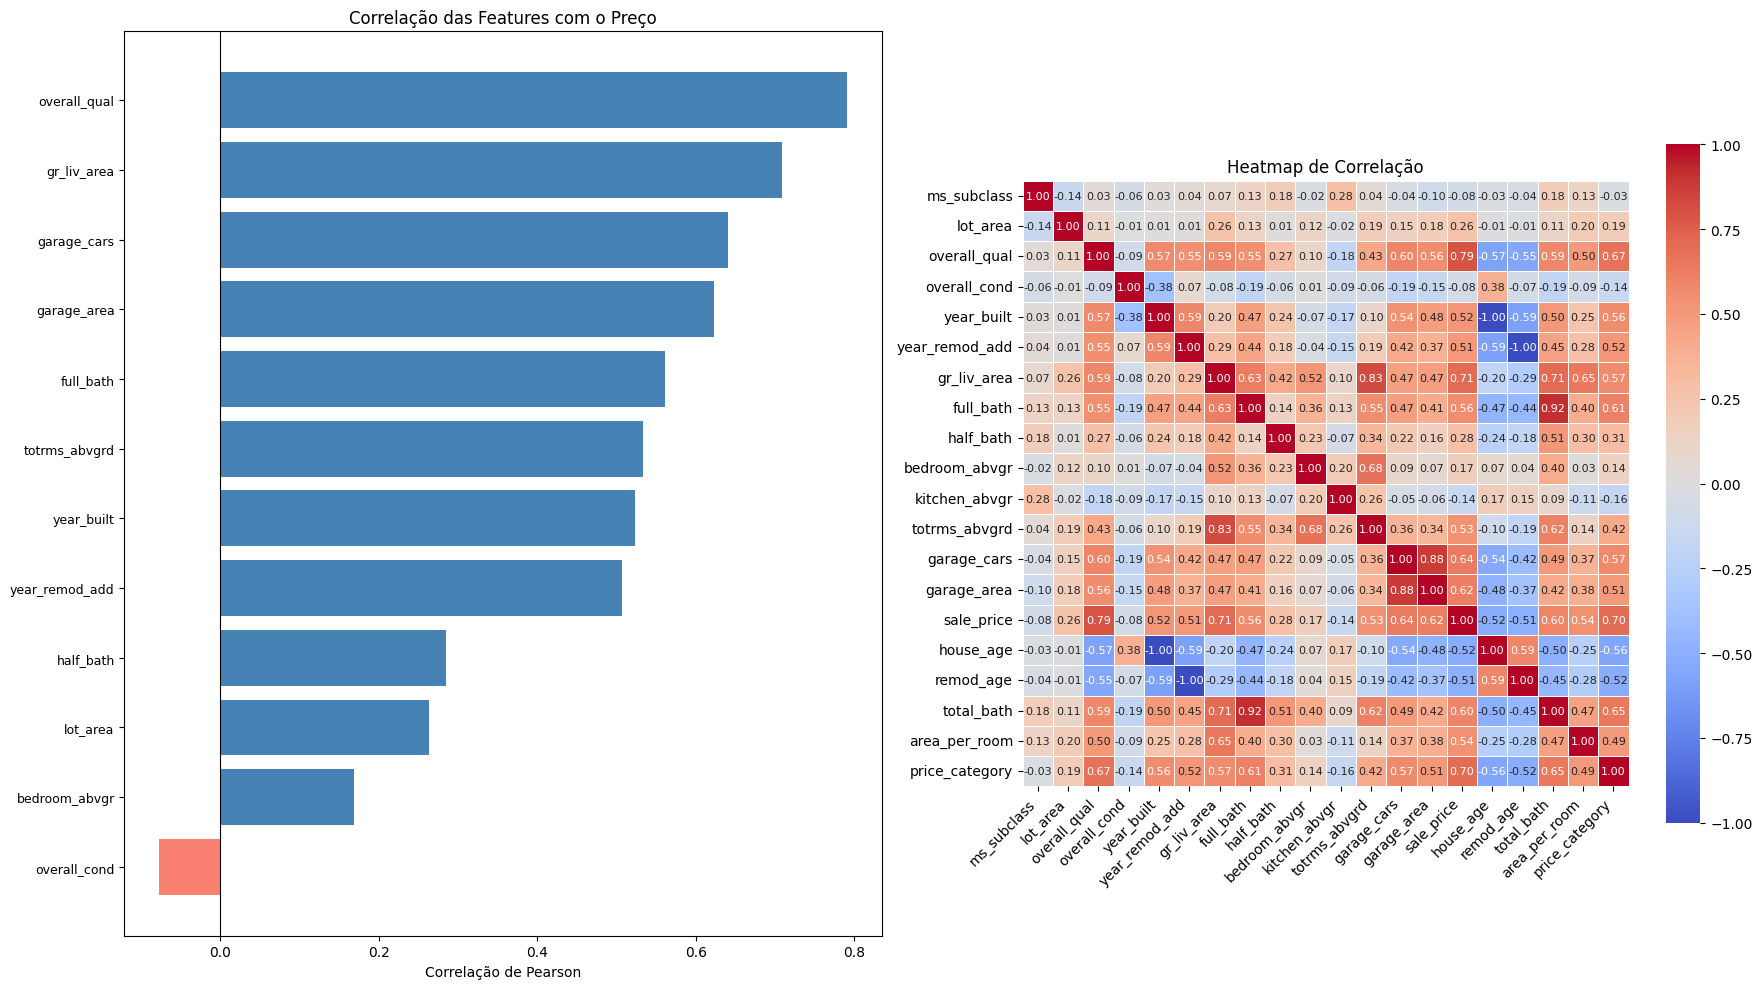

In [53]:
corr_data = conn.get_correlations(headers)
corr_series = pd.Series(corr_data['correlacao_com_preco']).drop('sale_price')

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Ordena por correlação para melhor leitura
corr_series = corr_series.sort_values()

# Barras de correlação
colors = ['steelblue' if v > 0 else 'salmon' for v in corr_series.values]
axes[0].barh(corr_series.index, corr_series.values, color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Correlação das Features com o Preço')
axes[0].set_xlabel('Correlação de Pearson')
axes[0].tick_params(axis='y', labelsize=9)

# Heatmap
numeric_df = df.select_dtypes(include='number').drop(columns=['id'], errors='ignore')
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1], annot_kws={'size': 8}, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.75})
axes[1].set_title('Heatmap de Correlação')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
plt.setp(axes[1].get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()



### 1.5 Distribuição das Variáveis Mais Relevantes

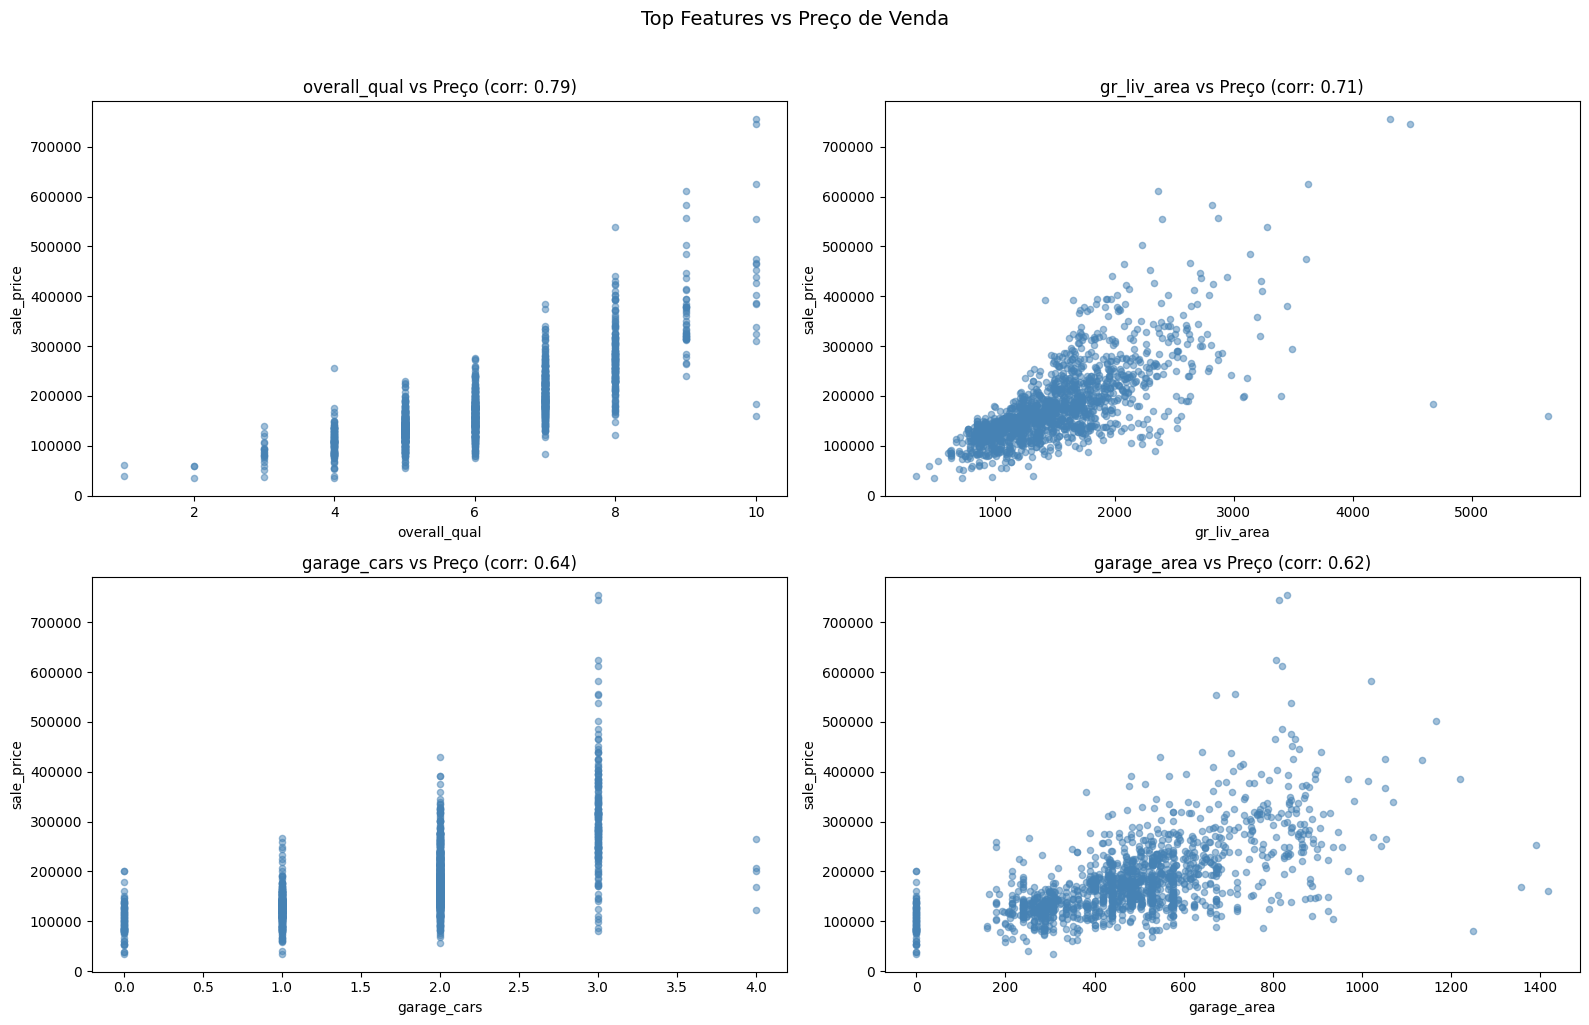

In [54]:
top_features = corr_series.abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df['sale_price'], alpha=0.5, color='steelblue', s=20)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('sale_price')
    axes[i].set_title(f'{feat} vs Preço (corr: {corr_series[feat]:.2f})')

plt.suptitle('Top Features vs Preço de Venda', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 1.6 Preço por Bairro

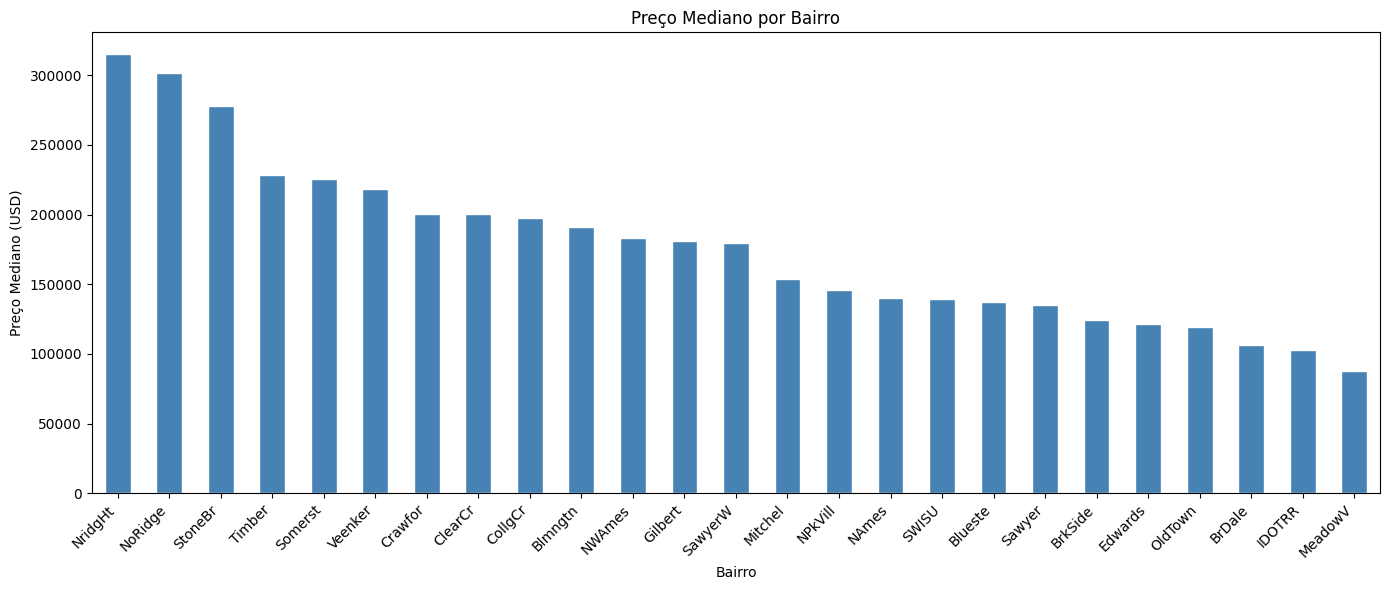

In [55]:
preco_bairro = df.groupby('neighborhood')['sale_price'].median().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
preco_bairro.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Preço Mediano por Bairro')
plt.xlabel('Bairro')
plt.ylabel('Preço Mediano (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


---
## 2. Feature Engineering
### 2.1 Novas Features Criadas

In [56]:
print('Novas Features')
print("""
  house_age    = 2024 - year_built      → Idade da casa
  remod_age    = 2024 - year_remod_add  → Anos desde a última reforma
  total_bath   = full_bath + 0.5*half_bath → Total de banheiros
  area_per_room = gr_liv_area / totrms_abvgrd → Área média por cômodo
  price_category = 1 se acima da mediana, 0 caso contrário
""")

df['house_age'] = 2024 - df['year_built']
df['remod_age'] = 2024 - df['year_remod_add']
df['total_bath'] = df['full_bath'] + 0.5 * df['half_bath']
df['area_per_room'] = df['gr_liv_area'] / df['totrms_abvgrd']
df['price_category'] = (df['sale_price'] > df['sale_price'].median()).astype(int)

novas = ['house_age', 'remod_age', 'total_bath', 'area_per_room', 'price_category']
df[novas].describe().round(2)


Novas Features

  house_age    = 2024 - year_built      → Idade da casa
  remod_age    = 2024 - year_remod_add  → Anos desde a última reforma
  total_bath   = full_bath + 0.5*half_bath → Total de banheiros
  area_per_room = gr_liv_area / totrms_abvgrd → Área média por cômodo
  price_category = 1 se acima da mediana, 0 caso contrário



,house_age,remod_age,total_bath,area_per_room,price_category
count,1460.00,1460.00,1460.00,1460.00,1460.0
mean,52.73,39.13,1.76,230.91,0.5
std,30.20,20.65,0.64,44.74,0.5
min,14.00,14.00,0.00,120.00,0.0
25%,24.00,20.00,1.00,199.00,0.0
50%,51.00,30.00,2.00,226.50,0.0
75%,70.00,57.00,2.50,256.11,1.0
max,152.00,74.00,3.50,470.17,1.0
